# Final Evaluation and Model Export

## Notebook purpose

This notebook:

1. Compares all available model validation results.
2. Selects the winner using validation PR-AUC.
3. Uses the selected validation threshold.
4. Retrains the winning model using all data from 2021 to June 2025.
5. Evaluates the winner once on the untouched July to December 2025 test set.
6. Saves the final model artifact and metadata.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    StandardScaler,
)
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_SEED = 42
MODEL_VERSION = "return_risk_v1"

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Model output directory: {MODELS_DIR}")

Project root: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics
Model output directory: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\models


# Load Training Data and Validation Results

In [2]:
training_df = pd.read_csv(
    PROCESSED_DIR / "return_risk_training_data.csv"
)

baseline_results_df = pd.read_csv(
    PROCESSED_DIR / "baseline_model_validation_results.csv"
)

tree_results_df = pd.read_csv(
    PROCESSED_DIR / "tree_model_validation_results.csv"
)

training_df["order_timestamp"] = pd.to_datetime(
    training_df["order_timestamp"],
    errors="coerce"
)

print(f"Training-data rows: {len(training_df):,}")
print(f"Baseline models found: {len(baseline_results_df)}")
print(f"Tree models found: {len(tree_results_df)}")

Training-data rows: 123,021
Baseline models found: 1
Tree models found: 3


# Validate Leakage Safety

In [3]:
forbidden_columns = [
    "order_status",
    "return_status",
    "return_reason",
    "delivery_days",
    "delivery_status",
    "customer_rating",
    "review_sentiment",
    "customer_review",
    "payment_status",
    "loyalty_points_earned",
    "loyalty_points_redeemed",
    "estimated_delivery_days",
    "total_discount_amount",
    "maximum_discount_percentage",
    "average_discount_percentage",
    "order_discount_rate",
]

present_forbidden_columns = [
    column
    for column in forbidden_columns
    if column in training_df.columns
]

assert training_df["order_timestamp"].isna().sum() == 0
assert set(training_df["return_label"].unique()) == {0, 1}
assert len(present_forbidden_columns) == 0, (
    f"Leakage columns found: {present_forbidden_columns}"
)

print("Leakage and target validation passed.")

Leakage and target validation passed.


# Compare Validation Results and Select Winner


In [4]:
all_validation_results_df = pd.concat(
    [baseline_results_df, tree_results_df],
    ignore_index=True,
)

required_result_columns = [
    "model",
    "pr_auc",
    "roc_auc",
    "best_threshold",
    "precision",
    "recall",
    "f1_score",
]

missing_result_columns = [
    column
    for column in required_result_columns
    if column not in all_validation_results_df.columns
]

assert not missing_result_columns, (
    f"Missing result columns: {missing_result_columns}"
)

assert all_validation_results_df["model"].is_unique, (
    "Each model must appear only once in validation results."
)

all_validation_results_df = (
    all_validation_results_df
    .sort_values(
        ["pr_auc", "f1_score", "roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(all_validation_results_df)

selected_model_row = all_validation_results_df.iloc[0]

selected_model_name = selected_model_row["model"]
selected_threshold = float(
    selected_model_row["best_threshold"]
)

print(f"Selected model: {selected_model_name}")
print(f"Validation PR-AUC: {selected_model_row['pr_auc']:.4f}")
print(f"Selected threshold: {selected_threshold:.2f}")

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,LightGBM,0.6264,0.9342,0.7000,0.6048,0.6225,0.6135
1,XGBoost,0.6241,0.9291,0.6500,0.5969,0.6124,0.6045
2,CatBoost,0.5932,0.9235,0.6500,0.4996,0.6629,0.5698
3,Logistic Regression,0.5684,0.9135,0.7000,0.5359,0.6449,0.5854


Selected model: LightGBM
Validation PR-AUC: 0.6264
Selected threshold: 0.70


# Create Final Chronological Training and Test Sets


In [5]:
pretest_end_date = pd.Timestamp("2025-06-30 23:59:59")
test_start_date = pd.Timestamp("2025-07-01")
test_end_date = pd.Timestamp("2025-12-31 23:59:59")

pretest_df = training_df[
    training_df["order_timestamp"] <= pretest_end_date
].copy()

test_df = training_df[
    (training_df["order_timestamp"] >= test_start_date)
    & (training_df["order_timestamp"] <= test_end_date)
].copy()

split_summary = pd.DataFrame([
    {
        "split": "Final training data",
        "rows": len(pretest_df),
        "start_date": pretest_df["order_timestamp"].min(),
        "end_date": pretest_df["order_timestamp"].max(),
        "return_rate_percent": pretest_df["return_label"].mean() * 100,
    },
    {
        "split": "Untouched test data",
        "rows": len(test_df),
        "start_date": test_df["order_timestamp"].min(),
        "end_date": test_df["order_timestamp"].max(),
        "return_rate_percent": test_df["return_label"].mean() * 100,
    },
])

display(split_summary)

assert len(pretest_df) > 0
assert len(test_df) > 0

,split,rows,start_date,end_date,return_rate_percent
0,Final training data,109042,2021-01-01 00:01:30,2025-06-30 23:38:51,7.6851
1,Untouched test data,13979,2025-07-01 00:02:13,2025-12-31 23:58:53,7.7402


# Select Model Features

In [6]:
target_column = "return_label"

non_feature_columns = [
    "order_id",
    "customer_id",
    "order_timestamp",
    "order_timestamp_customer",
    target_column,
]

feature_columns = [
    column
    for column in training_df.columns
    if column not in non_feature_columns
]

X_pretest = pretest_df[feature_columns].copy()
y_pretest = pretest_df[target_column].copy()

X_test = test_df[feature_columns].copy()

categorical_columns = X_pretest.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print(f"Model features: {len(feature_columns)}")
print(f"Categorical features: {len(categorical_columns)}")
print(f"Numeric features: {len(numeric_columns)}")

Model features: 50
Categorical features: 14
Numeric features: 36


# Create Model Preprocessing

In [7]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Unknown",
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=False)),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Unknown",
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ]
)


# Create the Selected Model Configuration

In [ ]:
def prepare_catboost_data(
    dataframe,
    categorical_columns,
):
    prepared_df = dataframe.copy()

    prepared_df = prepared_df.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    for column in categorical_columns:
        prepared_df[column] = (
            prepared_df[column]
            .fillna("Unknown")
            .astype(str)
        )

    return prepared_df


positive_class_weight = (
    (y_pretest == 0).sum()
    / (y_pretest == 1).sum()
)

if selected_model_name == "LightGBM":
    final_model = Pipeline([
        ("preprocessor", tree_preprocessor),
        (
            "model",
            LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=50,
                subsample=0.8,
                subsample_freq=1,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                scale_pos_weight=positive_class_weight,
                random_state=RANDOM_SEED,
                n_jobs=-1,
                verbosity=-1,
            ),
        ),
    ])

elif selected_model_name == "XGBoost":
    final_model = Pipeline([
        ("preprocessor", tree_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=5,
                reg_lambda=1.0,
                scale_pos_weight=positive_class_weight,
                objective="binary:logistic",
                eval_metric="aucpr",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ])

elif selected_model_name == "CatBoost":
    final_model = CatBoostClassifier(
        iterations=500,
        depth=7,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="PRAUC",
        class_weights=[1.0, positive_class_weight],
        random_seed=RANDOM_SEED,
        verbose=100,
        allow_writing_files=False,
    )

elif selected_model_name == "Logistic Regression":
    final_model = Pipeline([
        ("preprocessor", logistic_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="saga",
                random_state=RANDOM_SEED,
            ),
        ),
    ])
else:
    raise ValueError(
        f"Unsupported selected model: {selected_model_name}"
    )

print(f"Final model created: {selected_model_name}")

Final model created: LightGBM


# Train the Final Model



In [9]:
if selected_model_name == "CatBoost":
    X_pretest_model = prepare_catboost_data(
        X_pretest,
        categorical_columns,
    )

    X_test_model = prepare_catboost_data(
        X_test,
        categorical_columns,
    )

    final_model.fit(
        X_pretest_model,
        y_pretest,
        cat_features=categorical_columns,
    )

else:
    X_pretest_model = X_pretest
    X_test_model = X_test

    final_model.fit(
        X_pretest_model,
        y_pretest,
    )

print("Final model training completed.")

Final model training completed.


# Final Evaluation on the Untouched Test Period


In [10]:
y_test = test_df[target_column].copy()

test_probabilities = final_model.predict_proba(
    X_test_model
)[:, 1]

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

test_metrics = {
    "model": selected_model_name,
    "decision_threshold": selected_threshold,
    "test_pr_auc": average_precision_score(
        y_test,
        test_probabilities,
    ),
    "test_roc_auc": roc_auc_score(
        y_test,
        test_probabilities,
    ),
    "test_precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "test_recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "test_f1_score": f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "test_accuracy": accuracy_score(
        y_test,
        test_predictions,
    ),
    "test_return_rate": y_test.mean(),
}

test_metrics_df = pd.DataFrame([test_metrics])

display(test_metrics_df)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Not Returned",
            "Returned",
        ],
        zero_division=0,
    )
)

,model,decision_threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1_score,test_accuracy,test_return_rate
0,LightGBM,0.7000,0.8353,0.9696,0.7071,0.8142,0.7569,0.9595,0.0774



Classification report:
              precision    recall  f1-score   support

Not Returned       0.98      0.97      0.98     12897
    Returned       0.71      0.81      0.76      1082

    accuracy                           0.96     13979
   macro avg       0.85      0.89      0.87     13979
weighted avg       0.96      0.96      0.96     13979



# Test Confusion Matrix and Curves

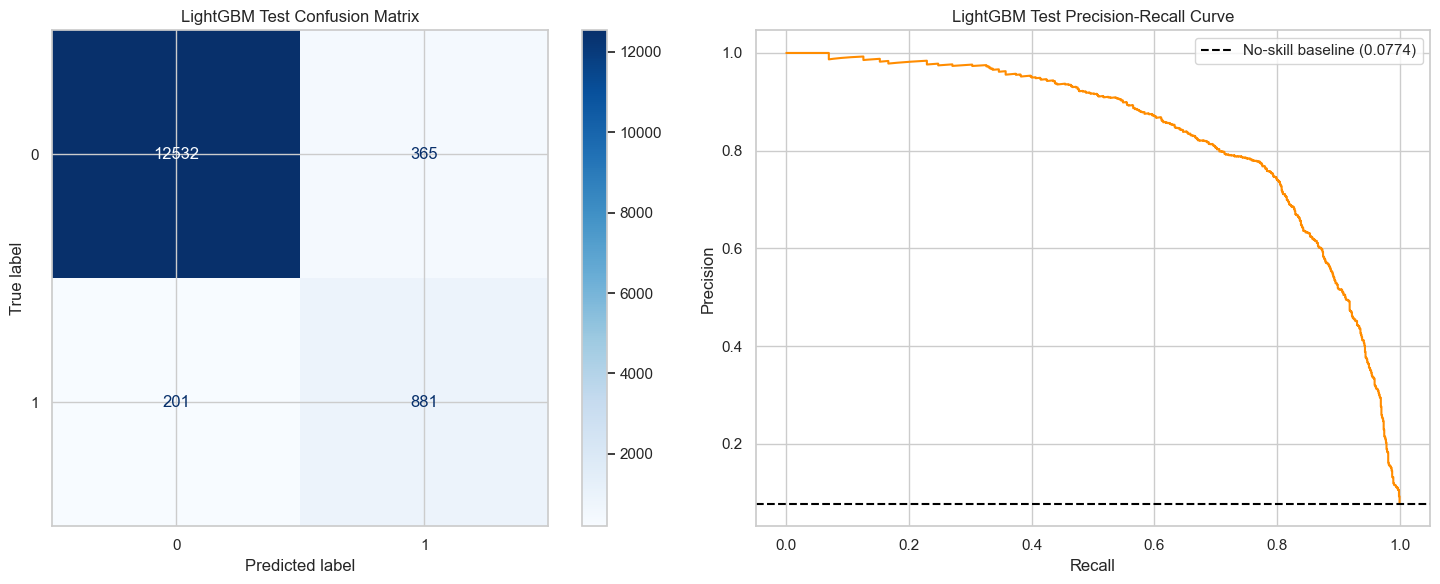

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    ax=axes[0],
    cmap="Blues",
)

axes[0].set_title(
    f"{selected_model_name} Test Confusion Matrix"
)

test_precision_curve, test_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_probabilities,
    )
)

axes[1].plot(
    test_recall_curve,
    test_precision_curve,
    color="darkorange",
)

axes[1].axhline(
    y_test.mean(),
    linestyle="--",
    color="black",
    label=(
        "No-skill baseline "
        f"({y_test.mean():.4f})"
    ),
)

axes[1].set_title(
    f"{selected_model_name} Test Precision-Recall Curve"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

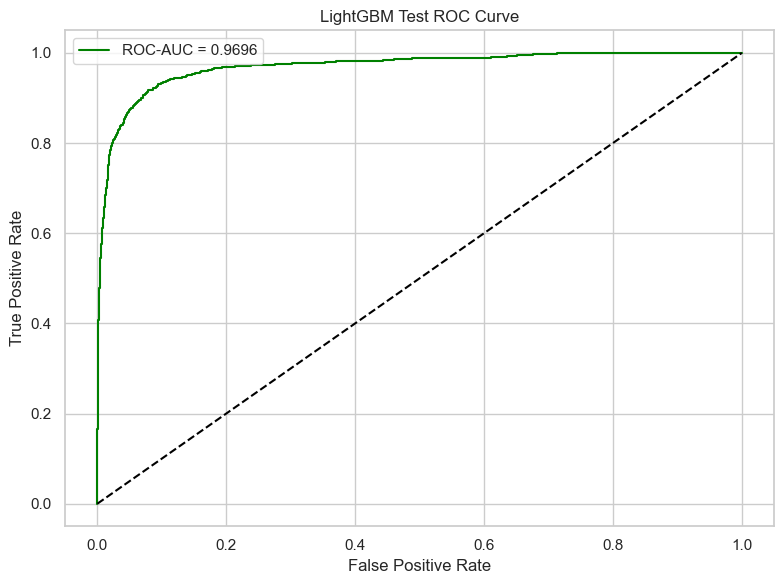

In [12]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    test_probabilities,
)

plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    color="green",
    label=(
        f"ROC-AUC = "
        f"{test_metrics['test_roc_auc']:.4f}"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
)

plt.title(
    f"{selected_model_name} Test ROC Curve"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance

,feature,importance
22,numeric__total_gross_sales,3584
25,numeric__total_item_net_sales,2494
27,numeric__total_item_profit,970
23,numeric__total_tax_amount,915
35,numeric__order_profit_margin_percentage,858
26,numeric__total_item_product_cost,587
0,numeric__order_month,448
17,numeric__total_quantity,325
24,numeric__total_shipping_cost,297
29,numeric__maximum_item_unit_price,285


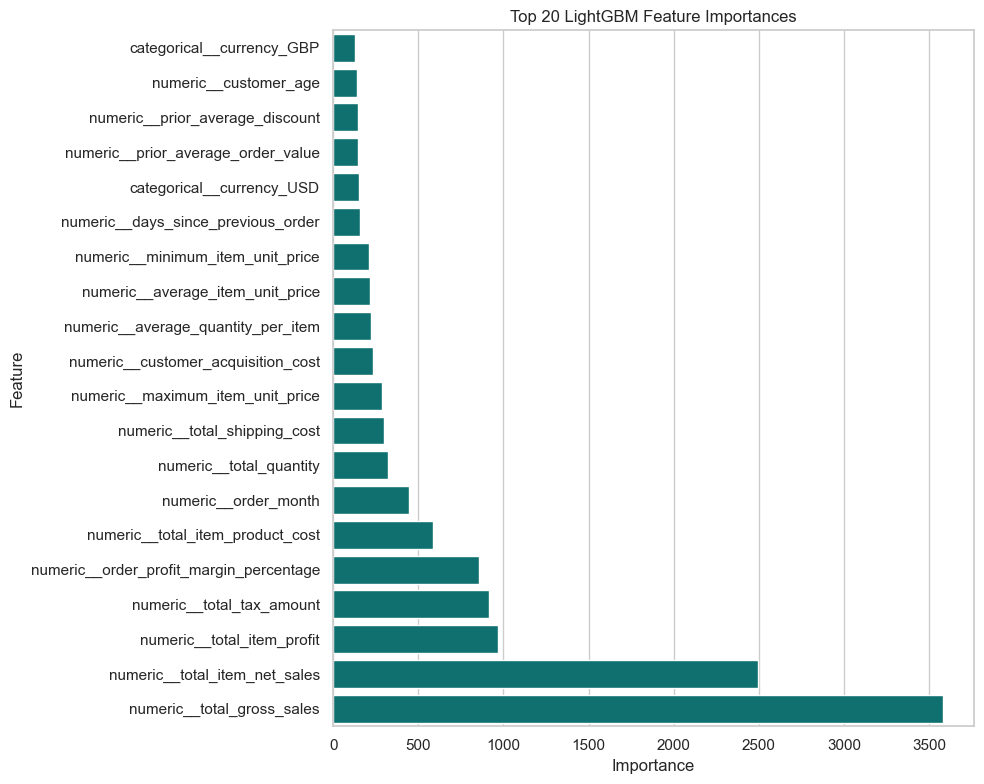

In [15]:
if selected_model_name in ["LightGBM", "XGBoost"]:
    transformed_feature_names = (
        final_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    importance_values = (
        final_model
        .named_steps["model"]
        .feature_importances_
    )

elif selected_model_name == "CatBoost":
    transformed_feature_names = feature_columns
    importance_values = final_model.feature_importances_

elif selected_model_name == "Logistic Regression":
    transformed_feature_names = (
        final_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    importance_values = np.abs(
        final_model
        .named_steps["model"]
        .coef_[0]
    )

else:
    transformed_feature_names = []
    importance_values = []

importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": importance_values,
})

top_features_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .head(20)
    .sort_values("importance")
)

display(top_features_df.sort_values(
    "importance",
    ascending=False,
))

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features_df,
    x="importance",
    y="feature",
    color="teal",
)

plt.title(
    f"Top 20 {selected_model_name} Feature Importances"
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save Final Model and Metadata

In [16]:
model_path = MODELS_DIR / f"{MODEL_VERSION}.joblib"
metadata_path = MODELS_DIR / f"{MODEL_VERSION}_metadata.json"

model_artifact = {
    "model": final_model,
    "model_name": selected_model_name,
    "model_version": MODEL_VERSION,
    "decision_threshold": selected_threshold,
    "feature_columns": feature_columns,
    "categorical_columns": categorical_columns,
}

metadata = {
    "model_version": MODEL_VERSION,
    "model_name": selected_model_name,
    "decision_threshold": selected_threshold,
    "primary_selection_metric": "validation_pr_auc",
    "validation_selection_results": {
        key: (
            float(value)
            if isinstance(value, (float, np.floating))
            else value
        )
        for key, value in selected_model_row.to_dict().items()
    },
    "test_metrics": {
        key: (
            float(value)
            if isinstance(value, (float, np.floating))
            else value
        )
        for key, value in test_metrics.items()
    },
    "feature_columns": feature_columns,
    "categorical_columns": categorical_columns,
    "training_period": {
        "start": str(pretest_df["order_timestamp"].min()),
        "end": str(pretest_df["order_timestamp"].max()),
        "rows": int(len(pretest_df)),
    },
    "test_period": {
        "start": str(test_df["order_timestamp"].min()),
        "end": str(test_df["order_timestamp"].max()),
        "rows": int(len(test_df)),
    },
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "leakage_excluded_columns": forbidden_columns,
}

joblib.dump(
    model_artifact,
    model_path,
)

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(
        metadata,
        file,
        indent=4,
    )

print(f"Saved model artifact: {model_path}")
print(f"Saved model metadata: {metadata_path}")

Saved model artifact: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\models\return_risk_v1.joblib
Saved model metadata: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\models\return_risk_v1_metadata.json
